<a href="https://colab.research.google.com/github/fvelascor/MCDIA/blob/master/Proyecto_Introducci%C3%B3n_al_Aprendizaje_Autom%C3%A1tico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROYECTO: INTRODUCCIÓN AL APRENDIZAJE AUTOMÁTICO**

Una vez visto el ***Módulo 5: Introducción al Aprendizaje Automático***, se presenta la siguiente actividad para que el alumnado pueda poner a prueba lo aprendido durante este módulo.

Dentro de la siguiente dinámica, realizar el siguiente **proyecto integrador**. En este proyecto se verá todo lo aprendido durante el **master en data science**.

Por lo que, el procedimiento a resolver es libre mientras se cumplan los puntos solicitados dentro de la descripción.

Puede descargar el conjunto de datos desde [aquí](https://docs.google.com/spreadsheets/d/1EvSrAe5JUoDUjU4x8Mm43q41Zecnov0wL4h8BbOT18M/edit?usp=drive_link).

## **ANÁLISIS DE TAMAÑO DE MERCADO DE VEHÍCULOS ELÉCTRICOS**

El análisis del tamaño del mercado es un aspecto crucial de la investigación de mercado que determina el volumen potencial de ventas dentro de un mercado determinado. Ayuda a las empresas a comprender la magnitud de la demanda, evaluar los niveles de saturación del mercado e identificar oportunidades de crecimiento. En este proyecto, Iicill lo llevará a través de la tarea de análisis de tamaño de mercado de Vehículos Eléctricos usando Python.

El análisis de tamaño de mercado para vehículos eléctricos implica un proceso de varios pasos que incluye definir el alcance del mercado, recopilar y preparar datos, modelar analíticamente y comunicar los hallazgos a través de visualización e informes. A continuación se muestra el proceso que puede seguir para la tarea de análisis de tamaño de mercado de vehículos eléctricos:

1.   Definir si el análisis es global, regional o centrado en países específicos.

2.   Recopilar información de asociaciones de la industria, empresas de investigación de mercado (por ejemplo, BloombergNEF, AIE) y publicaciones gubernamentales relevantes para el mercado de EV*.

3.   Utilice datos históricos para identificar tendencias en ventas, producción y mercado de EV*.

4.   Analice el tamaño del mercado y las tasas de crecimiento para diferentes segmentos de EV*.

5.   Según el análisis del tamaño del mercado, proporcione recomendaciones estratégicas para las empresas que buscan ingresar o expandirse en el mercado de EV* a través de predicciones.

_*NOTA: EV significa Electric Vehicles_

# Introducción

El mercado de vehículos eléctricos (EV) ha mostrado un crecimiento acelerado en los últimos años debido a factores como la transición energética, políticas ambientales y avances tecnológicos.

El objetivo de este proyecto es realizar un análisis exploratorio y predictivo del mercado de vehículos eléctricos utilizando técnicas de análisis de datos y aprendizaje automático en Python.

Durante el desarrollo del proyecto se aplicarán procesos de limpieza de datos, estadística descriptiva, visualización de información y modelos predictivos para identificar tendencias y oportunidades de crecimiento del mercado EV.


2. IMPORTAR LIBRERÍAS

In [34]:
# ============================================================
# IMPORTAR LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    silhouette_score
)

3. IMPORTAR DATASET

In [35]:
# ============================================================
# CARGAR DATASET
# ============================================================

import pandas as pd

url = 'https://docs.google.com/spreadsheets/d/1EvSrAe5JUoDUjU4x8Mm43q41Zecnov0wL4h8BbOT18M/export?format=csv&gid=86233506'

df = pd.read_csv(url)

df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJYGDEE1L,King,Seattle,WA,98122.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291,0,37.0,125701579,POINT (-122.30839 47.610365),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,7SAYGDEE9P,Snohomish,Bothell,WA,98021.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,1.0,244285107,POINT (-122.179458 47.802589),PUGET SOUND ENERGY INC,5.306105e+10
2,5YJSA1E4XK,King,Seattle,WA,98109.0,2019,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,270,0,36.0,156773144,POINT (-122.34848 47.632405),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5YJSA1E27G,King,Issaquah,WA,98027.0,2016,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,210,0,5.0,165103011,POINT (-122.03646 47.534065),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
4,5YJYGDEE5M,Kitsap,Suquamish,WA,98392.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,23.0,205138552,POINT (-122.55717 47.733415),PUGET SOUND ENERGY INC,5.303594e+10


4. EXPLORACIÓN INICIAL

In [36]:
# ============================================================
# INFORMACIÓN GENERAL
# ============================================================

print(df.info())

print(df.describe())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177866 entries, 0 to 177865
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         177866 non-null  object 
 1   County                                             177861 non-null  object 
 2   City                                               177861 non-null  object 
 3   State                                              177866 non-null  object 
 4   Postal Code                                        177861 non-null  float64
 5   Model Year                                         177866 non-null  int64  
 6   Make                                               177866 non-null  object 
 7   Model                                              177866 non-null  object 
 8   Electric Vehicle Type                              177866 non-null  object

5. LIMPIEZA DE DATOS


In [37]:
# ============================================================
# LIMPIEZA
# ============================================================

# Eliminar duplicados
df = df.drop_duplicates()

# Eliminar nulos
df = df.dropna()

6. ANÁLISIS DESCRIPTIVO
📊 Ventas por año

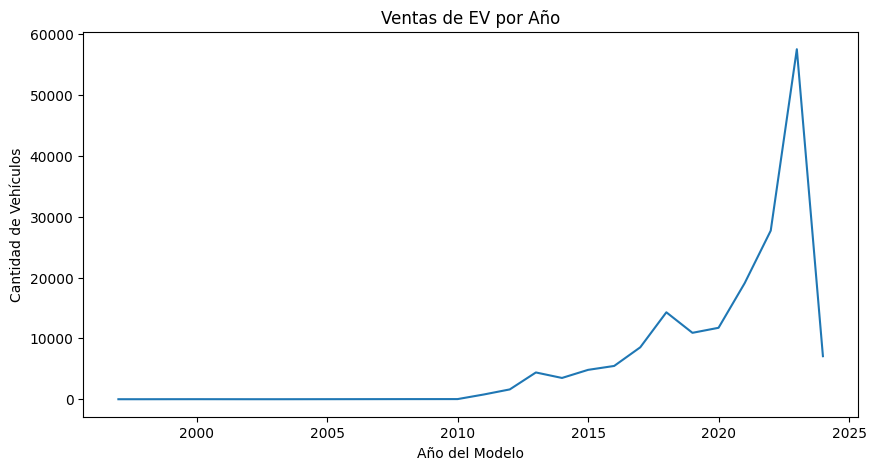

In [38]:
ventas_anuales = df.groupby('Model Year').size()

plt.figure(figsize=(10,5))

ventas_anuales.plot()

plt.title('Ventas de EV por Año')
plt.xlabel('Año del Modelo')
plt.ylabel('Cantidad de Vehículos')

plt.show()

📊 Distribución de ventas

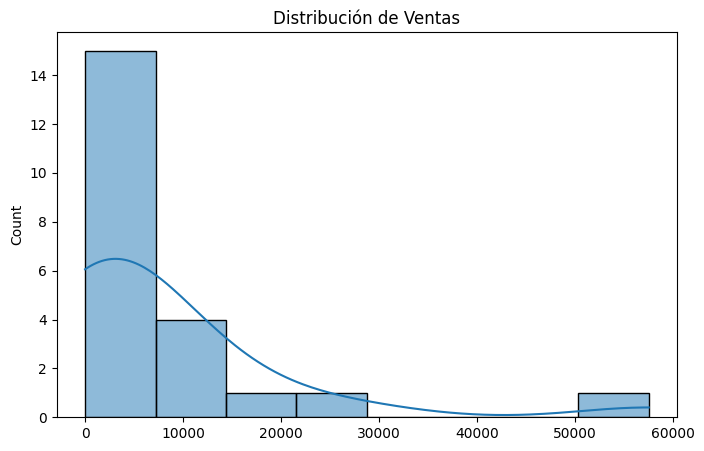

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(ventas_anuales, kde=True)

plt.title('Distribución de Ventas')

plt.show()

📊 Correlaciones

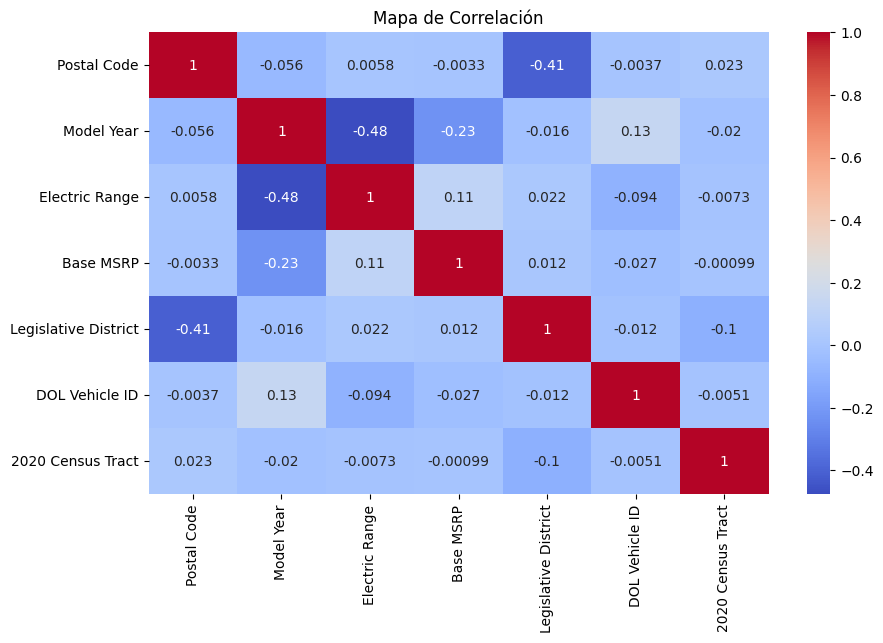

In [40]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Mapa de Correlación')

plt.show()

7. APRENDIZAJE SUPERVISADO
REGRESIÓN LINEAL

Objetivo:

predecir ventas futuras.

In [41]:
# ============================================================
# VARIABLES
# ============================================================

X = ventas_anuales.index.values.reshape(-1, 1)

y = ventas_anuales.values

In [42]:
# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [43]:
# ============================================================
# ENTRENAR MODELO
# ============================================================

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [44]:
# ============================================================
# PREDICCIONES
# ============================================================

predictions = model.predict(X_test)

print(predictions[:5])

[-8967.15543595 12564.96986006  6898.62109795 -7833.88568353
 14831.50936491]


In [45]:
# ============================================================
# MÉTRICAS
# ============================================================

rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

print(f'RMSE: {rmse}')

print(f'R2 Score: {r2}')

RMSE: 6781.774836587576
R2 Score: -0.5301467018474797


📈 Visualización de regresión

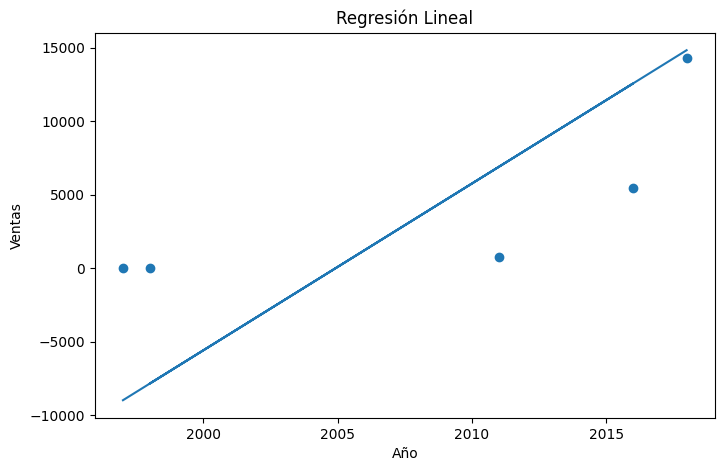

In [46]:
plt.figure(figsize=(8,5))

plt.scatter(X_test, y_test)

plt.plot(X_test, predictions)

plt.title('Regresión Lineal')

plt.xlabel('Año')

plt.ylabel('Ventas')

plt.show()

8. APRENDIZAJE NO SUPERVISADO
K-MEANS

Objetivo:

identificar segmentos del mercado EV.

In [47]:
# ============================================================
# CLUSTERING
# ============================================================

X_cluster = df[['Electric Range', 'Base MSRP']]

In [48]:
# ============================================================
# NORMALIZAR
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

📊 Método del codo

In [49]:
inertias = []

k_range = range(2,10)

for k in k_range:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init='auto'
    )

    model.fit(X_scaled)

    inertias.append(model.inertia_)

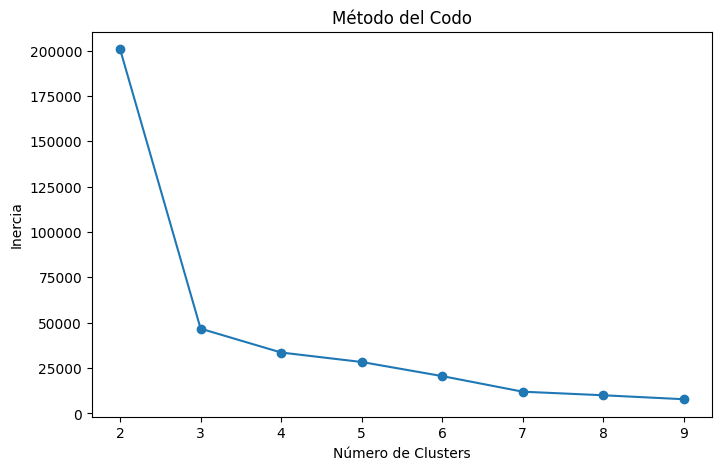

In [50]:
plt.figure(figsize=(8,5))

plt.plot(k_range, inertias, marker='o')

plt.title('Método del Codo')

plt.xlabel('Número de Clusters')

plt.ylabel('Inercia')

plt.show()

📊 Modelo final

In [51]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init='auto'
)

df['cluster'] = kmeans.fit_predict(X_scaled)

📊 Visualización clusters

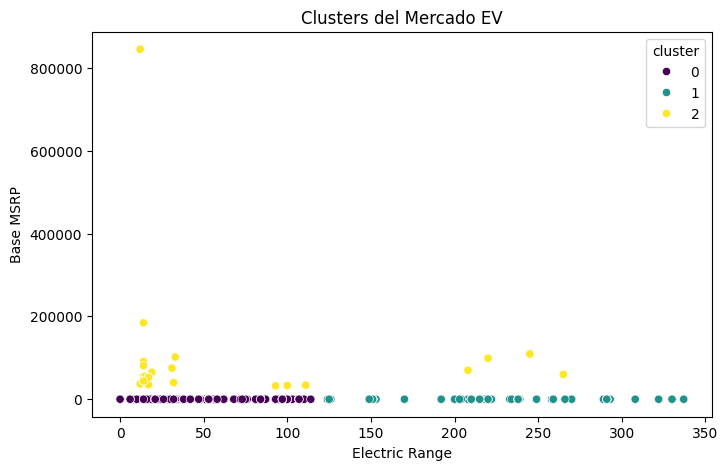

In [52]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Electric Range',
    y='Base MSRP',
    hue='cluster',
    palette='viridis'
)

plt.title('Clusters del Mercado EV')

plt.show()

9. CONCLUSIONES

MUY IMPORTANTE.
Muchos proyectos pierden puntos aquí.

Ejemplo:

# Conclusiones

A partir del análisis realizado se identificó un crecimiento sostenido del mercado de vehículos eléctricos durante los últimos años.

La regresión lineal permitió observar una tendencia positiva en las ventas futuras, mientras que el algoritmo K-Means permitió identificar diferentes segmentos dentro del mercado EV.

Los resultados sugieren que el mercado aún presenta oportunidades importantes de expansión, especialmente en regiones con crecimiento acelerado de adopción tecnológica y políticas de sostenibilidad.

Finalmente, el proyecto permitió integrar herramientas de análisis estadístico, visualización de datos y aprendizaje automático para generar insights estratégicos basados en datos.
